**Lab 3: Spectral Representation**

The goal of this lab is to gain familiarity with the spectral representations of signals, specially the spectrograms.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram, plot_spectrum_at

First upload your reference signal and plot the first seconds of it.

In [4]:
filepath = "audio/so_guitarra.wav"
ref, fs = load_audio(filepath)
plot_signals(ref, fs)

# **Exercises**

**1. Spectrograms**

A spectrogram is obtained by estimating the frequency content in short sections of the signal. The magnitude of the spectrum over individual sections is plotted as intensity or color on a two-dimensional plot versus frequency and time. The length of each section, or window length, determines the frequency resolution. Longer windows give good frequency resolution but fail to
track frequency changes well. Shorter windows have poor frequency resolution, but good tracking.

In Python the function `spectrogram` from the `scipy.signal` package will
compute the spectrogram. A common call to the function is defined as follows. No need to understand the meaning of each parameter at this stage. Note that we provide the `plot_spectrogram` function to plot the spectrogram.

In [31]:
from scipy.signal import spectrogram

We can plot the spectrum (one slice of the spectrogram) of the signal at an specific time using the `plot_spectrum_at` function. For instance, we can see the spectrum of the signal at the 0.5 seconds:

In [32]:
ff, tt, Sxx = spectrogram(ref, fs) #Calculem l'espectrograma del senyal d'àudio ref amb freq de mostreig fs

plot_spectrum_at(ff, tt, Sxx, time = 0.5) #Mostrem l'espectre a t=0.5

1.1. Calculate and plot the spectrogram of your reference signal. Use `plt.ylim` to select the limits of the y axis in order to zoom in the frequency region of interest. For instance if you want to see the region between 0 and 4000 Hz, you can call `plt.ylim([0, 4000])` after the `plot_spectrogram` function.


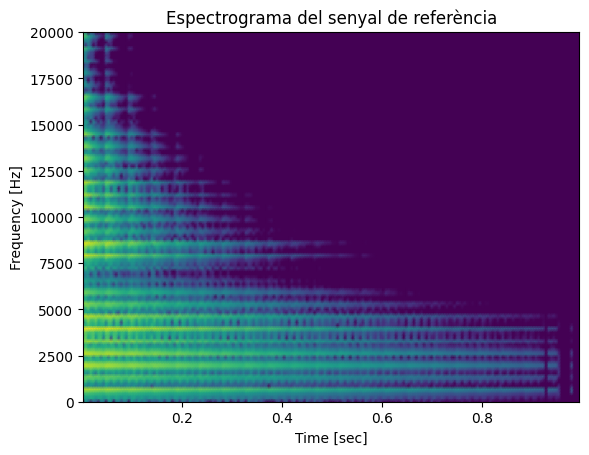

In [33]:
ff, tt, Sxx = spectrogram(ref, fs)

plot_spectrogram(ff, tt, Sxx) #Dibuixem l'espectrograma
plt.title("Espectrograma del senyal de referència") #Posem el títol
plt.ylim([0, 20000]) #Agafo l'interval [0, 20.000] perquè el [0, 4.000] no s'observava tan bé
plt.show() #Mostrem

1.2. Select a time where almost all harmonics are present and plot the spectrum at that time.

In [34]:
#Un temps on quasi tots els harmònics són presents és a t=0.1 segons, tot i que podem observar com
#hi ha bastantes perturbacions, ja que és la part inicial del so. Si vulguessim un so amb menys 
#perturbacions podríem escollir t=0.4, ja que, tot i contenir menys harmònics, el seu senyal és més net
t_all_harmonics = 0.1
plot_spectrum_at(ff, tt, Sxx, t_all_harmonics)

1.3. Use the cursor for measuring the weights of the fundamental frequency and some harmonics (6-10)

In [ ]:
#Per trobar els weights, calculem les freq múltiples de la fonamental (podem observar que f0 és 689 Hz)
freq = [4134, 4823, 5512, 6201, 6890] 

#Posem els weights respectius
weights = [0.1627, 0.0462, 0.0429, 0.0598, 0.0122]

**2. Synthesis**:

Let's define a function to synthetize an harmonic singal which receives the fundamental frequency ($f_0$) and the weights ($A_k$) of each harmonic and the time vector ($t$). This is similar to what you did in Lab 3- Ex3.2.


In [8]:
def synthesize(f0, phi, Ak, t):
  y = 0
  for k in range(1, len(Ak) + 1):
    y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
  return y

2.1. Use the `synthetize` function to generate a synthesis with the weights ($A_k$) found in 1.3 and the fundamental frequency and phases found in previous labs. Plot both the reference and the synthetize signal. Listen to the synthetize signal.

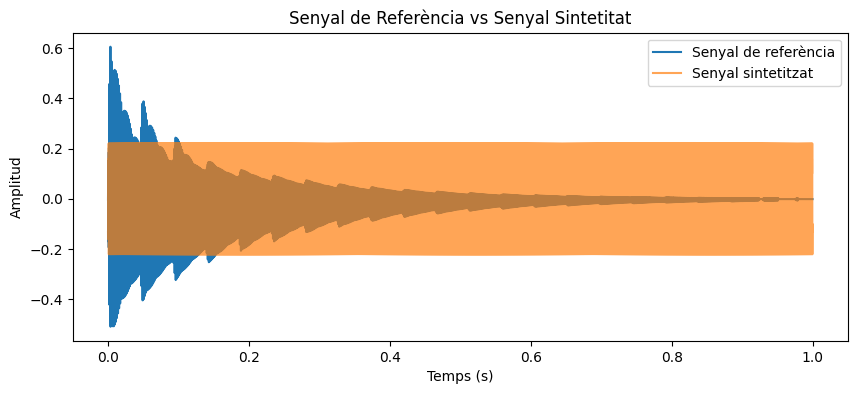

In [25]:
from IPython.display import Audio

#Repetim les variables
f0 = 689
fs = 44100
phi = np.pi
weights = [0.1627, 0.0462, 0.0429, 0.0598, 0.0122]
durada = 1
t = np.linspace(0, durada, int(fs*durada)) #Durada de 0 a 1 segon amb fs mostres per segon

syn = synthesize(f0, phi, weights, t)   #Cridem la funció

plt.figure(figsize = (10,4))    #Creem una figura 10x4
plt.plot(t, ref[:len(t)], label = "Senyal de referència")#Dibuixem el senyal original (ref) 
                                                        #en funció de t i amb la mateixa longitud que t
plt.plot(t, syn, label = "Senyal sintetitzat", alpha = 0.7)#Dibuixem el senyal sintetitzat (syn) en
                                                        #funció de t
plt.xlabel("Temps (s)") #T´tiol eix X
plt.ylabel("Amplitud") #Títol eix Y
plt.title("Senyal de Referència vs Senyal Sintetitat") #Títol de la gràfica
plt.legend() #Llegenda
plt.show() #Mostrem

Audio(syn, rate = fs) #Escoltem el senyal sintetitzat

2.2. Calculate the spectrogram of the synthesized signal `S_synt`; and compare the spectrums of both signals at the same time using `plot_spectrum_at(ff, tt, [S_ref, S_synt], time)`, where `S_ref`is spectrogram of the reference signal.

**Note:** use the same window length to calculate both spectrograms.

In [38]:
from scipy.signal import spectrogram

#Espectroghrama del senyal original
ff, tt, Sxx = spectrogram(ref, fs)
S_ref = Sxx

#Espectrograma del senyal sintetitzat
ff_s, tt_s, Sxx_s = spectrogram(syn, fs)
S_synt = Sxx_s

#Comparem els espectres a time = 0.4
plot_spectrum_at(ff, tt, [S_ref, S_synt], time = 0.4)

2.3. Compare the spectrograms of the two signals. What are the main differences?

Podem observar que el senyal de referència (blau) té un espectre més ric, amb molts components de freqüència i amplituds irregulars, representant clarament a un so natural.
D'altra banda, el senyal sinteitzat (taronja) mostra uns quants harmònics ben definits, separats de manera regular i amb amplituds més regulars, que no s'acaben d'ajustar a les del senyal original.

2.4. Listen to the two audios (reference and synthesized). What are the main differences?

In [42]:
print("Senyal de referència:")
display(Audio(ref, rate = fs)) #Escoltem el senyal de referència

print("Senyal sintetitzat:")
display(Audio(syn, rate = fs)) #Escoltem el senyal sintetitzat

Senyal de referència:


Senyal sintetitzat:


Podem observar com el senyal de referència és més suau, agradable i natural, mentre que el senyal sintetitzat encara sembla molt electrònic. A més a més, el soroll és gairebé constant a tot el senyal, fet que impedeix que vagi decaient amb el temps.